# Sizing & Drawing of Inverter

**Copyright 2026 Simon Dorrer and Harald Pretl**

SPDX-License-Identifier: Apache-2.0 WITH SHL-2.1


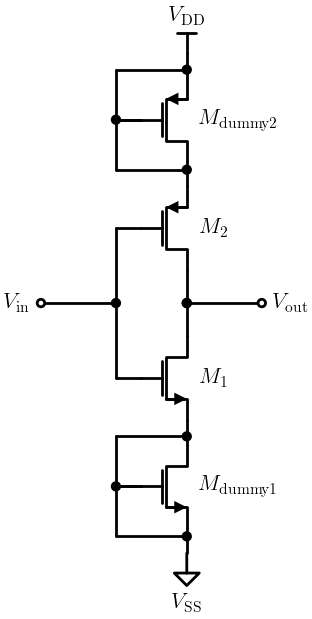

In [54]:
# Draw Circuit
import matplotlib
matplotlib.rcParams.update({
    "text.usetex": True,
    "font.family": "lmodern"
})
import schemdraw as sd
import schemdraw.elements as elm
sd.svgconfig.svg2 = False

with sd.Drawing() as d:
    d.config(unit=2, fontsize=16)

    elm.Dot(open=True).label(r'$V_\mathrm{in}$', loc='left', ofst=0.15)
    dot_in = elm.Line().right().length(1.5).dot()
    elm.Line().up().length(1.5)
    elm.Line().right().length(0.5)
    M2 = elm.AnalogPFet(offset_gate=False).anchor('gate').label(r'$M_{2}$', ofst=-1.75).reverse()
    elm.Line().at(M2.source).up().length(0.50)
    Mdummy2 = elm.AnalogPFet(offset_gate=False).anchor('drain').theta(0).label(r'$M_\mathrm{dummy2}$', ofst=-2.75).reverse()
    elm.Line().at(Mdummy2.source).up().length(0.5)
    VDD = elm.Vdd(lead=True).label('$V_\mathrm{DD}$', loc='top', ofst=0.15)
    elm.Line().at(Mdummy2.gate).left().length(0.5).dot()
    elm.Line().up().length(1.0)
    elm.Line().right().tox(Mdummy2.source).dot()
    elm.Line().at(Mdummy2.gate).left().length(0.5)
    elm.Line().down().length(1.0)
    elm.Line().right().tox(Mdummy2.source).dot()
    elm.Line().at(M2.drain).down().toy(dot_in.end).dot()
    elm.Line().right().length(1.5)
    elm.Dot(open=True).label(r'$V_\mathrm{out}$', loc='right', ofst=0.15)

    elm.Line().at(dot_in.end).down().length(1.5)
    elm.Line().right().length(0.5)
    M1 = elm.AnalogNFet(offset_gate=False).anchor('gate').label(r'$M_{1}$', ofst=-1.75).reverse()
    elm.Line().at(M1.source).down().length(0.50)
    Mdummy1 = elm.AnalogNFet(offset_gate=False).anchor('drain').theta(0).label(r'$M_\mathrm{dummy1}$', ofst=-2.75).reverse()
    elm.Line().at(Mdummy1.source).down().length(0.5)
    VSS = elm.GroundSignal(lead=True).label('$V_\mathrm{SS}$', loc='bottom', ofst=0.15)
    elm.Line().at(Mdummy1.gate).left().length(0.5).dot()
    elm.Line().down().length(1.0)
    elm.Line().right().tox(Mdummy1.source).dot()
    elm.Line().at(Mdummy1.gate).left().length(0.5)
    elm.Line().up().length(1.0)
    elm.Line().right().tox(Mdummy1.source).dot()
    elm.Line().at(M1.drain).up().toy(dot_in.end).dot()

    # Save the schematic
    d.save('figures/inverter_circuit.svg')
    d.save('figures/inverter_circuit.pdf')

# Specifications

In [55]:
# Supply voltage
VDD = 1.5

# Input common-mode voltage
Vcm_in = VDD / 2

# Output common-mode voltage
Vcm_out = VDD / 2

# Output current
i_out = 1.5e-3 / 2

# Length per inverter type (PMOS and NMOS share the same length within each inverter)
# l = 0.13 # minimum length to maximize bandwidth and decrease area, but also increase mismatch and reduce gain
# l = 0.5  # tradeoff between gain, bandwidth, area, and mismatch
l = 1.0  # higher length to reduce mismatch and increase gain, but also increase area and reduce bandwidth

# Load capacitance
C_load = 10e-12

In [56]:
# Print Specifications
print("=" * 60)
print("Specifications:")
print("=" * 60)
print(f"Supply Voltage (VDD):          {VDD} V")
print(f"Input Common-Mode (Vcm_in):    {Vcm_in} V")
print(f"Output Common-Mode (Vcm_out):  {Vcm_out} V")
print(f"Output Current (i_out):        {i_out*1e3:.2f} mA")
print(f"Transistor Length (L):         {l} µm")
print(f"Load Capacitance (C_load):     {C_load*1e12:.2f} pF")
print("=" * 60)

Specifications:
Supply Voltage (VDD):          1.5 V
Input Common-Mode (Vcm_in):    0.75 V
Output Common-Mode (Vcm_out):  0.75 V
Output Current (i_out):        0.75 mA
Transistor Length (L):         1.0 µm
Load Capacitance (C_load):     10.00 pF


# Load SG13G2 Data Tables

In [57]:
from pygmid import Lookup as lk
import numpy as np
lv_nmos = lk('data/sg13g2_lv_nmos.mat')
lv_pmos = lk('data/sg13g2_lv_pmos.mat')
# list of parameters: VGS, VDS, VSB, L, W, NFING, ID, VT, GM, GMB, GDS, CGG, CGB, CGD, CGS, CDD, CSS, STH, SFL
# if not specified, minimum L, VDS=max(vgs)/2=0.9 and VSB=0 are used 

# Inverter Sizing

In [58]:
# NMOS Sizing
print("=" * 60)
print("NMOS Sizing:")
print("=" * 60, "\n")

# Vgs of NMOS
print(f"Bias Voltages:")
print("-" * 60)
Vgs_NMOS = Vcm_in
print(f"Vgs_NMOS = {Vgs_NMOS} V")

# Vds of NMOS
Vds_NMOS = Vcm_out
print(f"Vds_NMOS = {Vds_NMOS} V")
print("-" * 60 + "\n")

# Transconductance (gm)
print(f"Transconductance (gm):")
print("-" * 60)
gm_id_NMOS = lv_nmos.lookup("GM_ID", L=l, VGS=Vgs_NMOS, VDS=Vds_NMOS, VSB=0)
print(f"gm/ID(L, VGS, VDS, VSB) = {round(float(gm_id_NMOS), 2)} uS/uA")
gm_NMOS = i_out * gm_id_NMOS
print(f"gm_NMOS = {round(float(gm_NMOS) * 1e3, 2)}mS")
print("-" * 60 + "\n")

# Output Conductance (gds)
print(f"Output Conductance (gds):")
print("-" * 60)
gm_gds_NMOS = lv_nmos.lookup("GM_GDS", L=l, VGS=Vgs_NMOS, VDS=Vds_NMOS, VSB=0)
print(f"gm/gds(L, VGS, VDS, VSB) = {round(float(gm_gds_NMOS), 2)}")
gds_NMOS = gm_NMOS / gm_gds_NMOS
print(f"gds_NMOS = {round(float(gds_NMOS) * 1e3, 2)}mS")
print("-" * 60 + "\n")

# Gate capacitance (Cgg), Cgg = Cgs + Cgb + Cdb
print(f"Gate capacitance (Cgg), Cgg = Cgs + Cgb + Cdb:")
print("-" * 60)
gm_cgg_NMOS = lv_nmos.lookup("GM_CGG", L=l, VGS=Vgs_NMOS, VDS=Vds_NMOS, VSB=0)
Cgg_NMOS = gm_NMOS / gm_cgg_NMOS
print(f"Cgg_NMOS = {round(float(Cgg_NMOS) * 1e15, 2)}fF")
print("-" * 60 + "\n")

# Transit Frequency (fT) @ current gain = 1
print(f"Transit Frequency (fT) @ current gain = 1:")
f_T_NMOS = gm_cgg_NMOS / (2 * np.pi)
print(f"f_T_NMOS = {round(float(f_T_NMOS) * 1e-9, 2)}GHz")
print("-" * 60 + "\n")

# Width (W)
print(f"Width (W):")
print("-" * 60)
id_w_NMOS = lv_nmos.lookup("ID_W", L=l, VGS=Vgs_NMOS, VDS=Vds_NMOS, VSB=0)
print(f"ID/W(L, VGS, VDS, VSB) = {round(float(id_w_NMOS * 1e6), 2)} uA/um")
w_NMOS = i_out / id_w_NMOS
print(f"w_NMOS = {round(float(w_NMOS), 2)}um")
print("-" * 60 + "\n")

# Thermal Noise PSD at 1Hz (STH)
print(f"Thermal Noise PSD at 1Hz (STH):")
print("-" * 60)
sth_gm = lv_nmos.lookup('STH_GM', GM_ID=gm_id_NMOS, L=l, VDS=Vds_NMOS, VSB=0)
sth = sth_gm * gm_NMOS
print(f"STH(gm/ID, L, VDS, VSB) = {round(float(sth * 1e24), 2)} pV²/Hz (thermal noise psd at 1 Hz)")
print("-" * 60 + "\n")

# Flicker Corner Frequency (fco)
print(f"Flicker Corner Frequency (fco):")
print("-" * 60)
fco = lv_nmos.lookup('SFL_STH', GM_ID=gm_id_NMOS, L=l, VDS=Vds_NMOS, VSB=0)
print(f"fco(gm/ID, L, VDS, VSB) = {round(float(fco * 1e-6), 2)} MHz (flicker corner frequency @ flicker noise PSD = thermal noise PSD)")
print("=" * 60)

NMOS Sizing:

Bias Voltages:
------------------------------------------------------------
Vgs_NMOS = 0.75 V
Vds_NMOS = 0.75 V
------------------------------------------------------------

Transconductance (gm):
------------------------------------------------------------
gm/ID(L, VGS, VDS, VSB) = 3.76 uS/uA
gm_NMOS = 2.82mS
------------------------------------------------------------

Output Conductance (gds):
------------------------------------------------------------
gm/gds(L, VGS, VDS, VSB) = 28.93
gds_NMOS = 0.1mS
------------------------------------------------------------

Gate capacitance (Cgg), Cgg = Cgs + Cgb + Cdb:
------------------------------------------------------------
Cgg_NMOS = 154.32fF
------------------------------------------------------------

Transit Frequency (fT) @ current gain = 1:
f_T_NMOS = 2.91GHz
------------------------------------------------------------

Width (W):
------------------------------------------------------------
ID/W(L, VGS, VDS, VSB) = 44

In [59]:
# PMOS Sizing
print("=" * 60)
print("PMOS Sizing:")
print("=" * 60, "\n")

# Vgs of PMOS
print(f"Bias Voltages:")
print("-" * 60)
Vgs_PMOS = VDD - Vcm_in
print(f"Vgs_PMOS = {Vgs_PMOS} V")

# Vds of PMOS
Vds_PMOS = VDD - Vcm_out
print(f"Vds_PMOS = {Vds_PMOS} V")
print("-" * 60 + "\n")

# Transconductance (gm)
print(f"Transconductance (gm):")
print("-" * 60)
gm_id_PMOS = gm_id_NMOS # lv_pmos.lookup("GM_ID", L=l_MA, VGS=Vgs_PMOS, VDS=Vds_PMOS, VSB=0)
print(f"gm/ID(L, VGS, VDS, VSB) = {round(float(gm_id_PMOS), 2)} uS/uA")
gm_PMOS = i_out * gm_id_PMOS
print(f"gm_PMOS = {round(float(gm_PMOS) * 1e3, 2)}mS")
print("-" * 60 + "\n")

# Output Conductance (gds)
print(f"Output Conductance (gds):")
print("-" * 60)
gm_gds_PMOS = lv_pmos.lookup("GM_GDS", L=l, VGS=Vgs_PMOS, VDS=Vds_PMOS, VSB=0)
print(f"gm/gds(L, VGS, VDS, VSB) = {round(float(gm_gds_PMOS), 2)}")
gds_PMOS = gm_PMOS / gm_gds_PMOS
print(f"gds_PMOS = {round(float(gds_PMOS) * 1e3, 2)}mS")
print("-" * 60 + "\n")

# Gate capacitance (Cgg), Cgg = Cgs + Cgb + Cdb
print(f"Gate capacitance (Cgg), Cgg = Cgs + Cgb + Cdb:")
print("-" * 60)
gm_cgg_PMOS = lv_pmos.lookup("GM_CGG", L=l, VGS=Vgs_PMOS, VDS=Vds_PMOS, VSB=0)
Cgg_PMOS = gm_PMOS / gm_cgg_PMOS
print(f"Cgg_PMOS = {round(float(Cgg_PMOS) * 1e15, 2)}fF")
print("-" * 60 + "\n")

# Transit Frequency (fT) @ current gain = 1
print(f"Transit Frequency (fT) @ current gain = 1:")
f_T_PMOS = gm_cgg_PMOS / (2 * np.pi)
print(f"f_T_PMOS = {round(float(f_T_PMOS) * 1e-9, 2)}GHz")
print("-" * 60 + "\n")

# Width (W)
print(f"Width (W):")
print("-" * 60)
id_w_PMOS = lv_pmos.lookup("ID_W", L=l, VGS=Vgs_PMOS, VDS=Vds_PMOS, VSB=0)
print(f"ID/W(L, VGS, VDS, VSB) = {round(float(id_w_PMOS * 1e6), 2)} uA/um")
w_PMOS = i_out / id_w_PMOS
print(f"w_PMOS = {round(float(w_PMOS), 2)}um")
print("-" * 60 + "\n")

# Thermal Noise PSD at 1Hz (STH)
print(f"Thermal Noise PSD at 1Hz (STH):")
print("-" * 60)
sth_gm = lv_pmos.lookup('STH_GM', GM_ID=gm_id_PMOS, L=l, VDS=Vds_PMOS, VSB=0)
sth = sth_gm * gm_PMOS
print(f"STH(gm/ID, L, VDS, VSB) = {round(float(sth * 1e24), 2)} pV²/Hz (thermal noise psd at 1 Hz)")
print("-" * 60 + "\n")

# Flicker Corner Frequency (fco)
print(f"Flicker Corner Frequency (fco):")
print("-" * 60)
fco = lv_pmos.lookup('SFL_STH', GM_ID=gm_id_PMOS, L=l, VDS=Vds_PMOS, VSB=0)
print(f"fco(gm/ID, L, VDS, VSB) = {round(float(fco * 1e-6), 2)} MHz (flicker corner frequency @ flicker noise PSD = thermal noise PSD)")
print("=" * 60)

PMOS Sizing:

Bias Voltages:
------------------------------------------------------------
Vgs_PMOS = 0.75 V
Vds_PMOS = 0.75 V
------------------------------------------------------------

Transconductance (gm):
------------------------------------------------------------
gm/ID(L, VGS, VDS, VSB) = 3.76 uS/uA
gm_PMOS = 2.82mS
------------------------------------------------------------

Output Conductance (gds):
------------------------------------------------------------
gm/gds(L, VGS, VDS, VSB) = 99.94
gds_PMOS = 0.03mS
------------------------------------------------------------

Gate capacitance (Cgg), Cgg = Cgs + Cgb + Cdb:
------------------------------------------------------------
Cgg_PMOS = 824.86fF
------------------------------------------------------------

Transit Frequency (fT) @ current gain = 1:
f_T_PMOS = 0.54GHz
------------------------------------------------------------

Width (W):
------------------------------------------------------------
ID/W(L, VGS, VDS, VSB) = 6

In [60]:
# PMOS / NMOS Width Ratio
w_ratio = w_PMOS / w_NMOS
print(f"PMOS/NMOS Width Ratio (W_PMOS/W_NMOS) = {round(float(w_ratio), 2)}")

PMOS/NMOS Width Ratio (W_PMOS/W_NMOS) = 6.88


# Define Widths and Fingers

In [61]:
def calculate_finger_options(width1_um, width2_um, target_ratio, min_finger_width=1.0, max_finger_width=20.0, max_options=10, finger_width_step=1.0):
    """
    Calculate practicable finger configurations for two transistors maintaining their width ratio.
    Finger widths are constrained to multiples of finger_width_step (default: 0.5um).
    Only returns configurations with an even number of fingers.
    Both transistors must have the SAME number of fingers.
    
    Parameters:
    -----------
    width1_um : float
        Width of first transistor in micrometers (e.g., PMOS)
    width2_um : float
        Width of second transistor in micrometers (e.g., NMOS)
    target_ratio : float
        Target width ratio (width1 / width2)
    min_finger_width : float
        Minimum practical finger width in micrometers (default: 1.0um)
    max_finger_width : float
        Maximum practical finger width in micrometers (default: 20.0um)
    max_options : int
        Maximum number of options to return (default: 10)
    finger_width_step : float
        Step size for finger width in micrometers (default: 1.0um)
    
    Returns:
    --------
    list of tuples : (nf, fw1, fw2, actual_ratio, error_percent)
        nf: number of fingers (same for both transistors)
        fw1: finger width for transistor 1
        fw2: finger width for transistor 2
        List of viable configurations sorted by error and preference
    """
    
    combinations = []
    
    # Try different even numbers of fingers
    # Start from 2 and go up to a reasonable maximum
    max_nf = int(max(width1_um, width2_um) / min_finger_width) + 2
    
    for nf in range(2, max_nf + 1, 2):  # Only even numbers
        # Calculate required finger widths for this number of fingers
        fw1_exact = width1_um / nf
        fw2_exact = width2_um / nf
        
        # Round to nearest finger_width_step
        fw1 = round(fw1_exact / finger_width_step) * finger_width_step
        fw2 = round(fw2_exact / finger_width_step) * finger_width_step
        
        # Check if both finger widths are within acceptable range
        if (min_finger_width <= fw1 <= max_finger_width and 
            min_finger_width <= fw2 <= max_finger_width):
            
            # Calculate actual widths with rounded finger widths
            actual_width1 = nf * fw1
            actual_width2 = nf * fw2
            
            # Calculate actual ratio
            actual_ratio = actual_width1 / actual_width2
            
            # Calculate percentage error from target ratio
            error_percent = abs(actual_ratio - target_ratio) / target_ratio * 100
            
            # Add to combinations
            combinations.append((nf, fw1, fw2, actual_ratio, error_percent))
    
    # Sort by preference: minimize error (but less aggressive), then prefer good finger widths
    def preference_score(combo):
        nf, fw1, fw2, actual_ratio, error_percent = combo
        # Primary: minimize ratio error (less aggressive weight to allow more error)
        error_score = error_percent * 2  # Reduced from 10 to 2
        # Secondary: prefer finger widths around 3-8um range
        width_score1 = abs(fw1 - 5.0)
        width_score2 = abs(fw2 - 5.0)
        # Tertiary: prefer fewer fingers
        finger_score = nf * 0.01
        return error_score + width_score1 + width_score2 + finger_score
    
    combinations.sort(key=preference_score)
    
    return combinations[:max_options]

In [62]:
# Calculate finger configurations for all transistors
print("=" * 60)
print('Finger Configuration Options:')
print("=" * 60 + "\n")

# Inverter A
print("Inverter A:")
print("-" * 60)
print(f"Target: PMOS width = {round(float(w_PMOS), 2)}um, NMOS width = {round(float(w_NMOS), 2)}um")
print(f"Target ratio (PMOS/NMOS) = {round(float(w_ratio), 2)}")
print("-" * 60 + "\n")

inverter_a_options = calculate_finger_options(
    round(float(w_PMOS), 2), 
    round(float(w_NMOS), 2), 
    float(w_ratio),
    min_finger_width=1.0,
    max_finger_width=20.0,
    max_options=10,
    finger_width_step=1.0
)

for i, (nf, fw_p, fw_n, actual_ratio, error_pct) in enumerate(inverter_a_options[:5], 1):
    actual_w_p = nf * fw_p
    actual_w_n = nf * fw_n
    print(f"Option {i}:")
    print(f"  Number of fingers: {nf} (same for both)")
    print(f"  PMOS: {nf} fingers × {round(fw_p, 2)}um/finger = {round(actual_w_p, 2)}um")
    print(f"  NMOS: {nf} fingers × {round(fw_n, 2)}um/finger = {round(actual_w_n, 2)}um")
    print(f"  Actual ratio: {round(actual_ratio, 2)}, Error: {round(error_pct, 2)}%")
    print("-" * 60 + "\n")

print("Final Widths for Inverter A:")
# Extract values from the best option (first in the list)
if inverter_a_options:
    NF_PMOS, w_NF_PMOS, w_NF_NMOS, _, _ = inverter_a_options[3]
    w_PMOS = w_NF_PMOS * NF_PMOS
    print(f"w_PMOS = w_NF_PMOS * NF_PMOS = {round(w_NF_PMOS, 2)}um * {NF_PMOS} = {round(w_PMOS, 2)}um")

    NF_NMOS = NF_PMOS  # Same number of fingers for both
    w_NMOS = w_NF_NMOS * NF_NMOS
    print(f"w_NMOS = w_NF_NMOS * NF_NMOS = {round(w_NF_NMOS, 2)}um * {NF_NMOS} = {round(w_NMOS, 2)}um")
else:
    print("No suitable finger configuration found!")
print("=" * 60)

Finger Configuration Options:

Inverter A:
------------------------------------------------------------
Target: PMOS width = 115.74um, NMOS width = 16.83um
Target ratio (PMOS/NMOS) = 6.88
------------------------------------------------------------

Option 1:
  Number of fingers: 16 (same for both)
  PMOS: 16 fingers × 7.0um/finger = 112.0um
  NMOS: 16 fingers × 1.0um/finger = 16.0um
  Actual ratio: 7.0, Error: 1.8%
------------------------------------------------------------

Option 2:
  Number of fingers: 8 (same for both)
  PMOS: 8 fingers × 14.0um/finger = 112.0um
  NMOS: 8 fingers × 2.0um/finger = 16.0um
  Actual ratio: 7.0, Error: 1.8%
------------------------------------------------------------

Option 3:
  Number of fingers: 18 (same for both)
  PMOS: 18 fingers × 6.0um/finger = 108.0um
  NMOS: 18 fingers × 1.0um/finger = 18.0um
  Actual ratio: 6.0, Error: 12.75%
------------------------------------------------------------

Option 4:
  Number of fingers: 20 (same for both)
  PM

In [63]:
# NMOS Sizing with final width
print("=" * 60)
print("NMOS Sizing with final width:")
print("=" * 60, "\n")

# Output Current (i_out)
print(f"Output Current (i_out):")
print("-" * 60)
i_out = w_NMOS * id_w_NMOS
print(f"Output current with final width: i_out = w_NMOS * ID/W = {round(float(i_out) * 1e3, 2)} mA")
print("-" * 60 + "\n")

# Transconductance (gm)
print(f"Transconductance (gm):")
print("-" * 60)
gm_NMOS = i_out * gm_id_NMOS
print(f"gm_NMOS = {round(float(gm_NMOS) * 1e3, 2)}mS")
print("-" * 60 + "\n")

# Output Conductance (gds)
print(f"Output Conductance (gds):")
print("-" * 60)
gds_NMOS = gm_NMOS / gm_gds_NMOS
print(f"gds_NMOS = {round(float(gds_NMOS) * 1e3, 2)}mS")
print("-" * 60)

NMOS Sizing with final width:

Output Current (i_out):
------------------------------------------------------------
Output current with final width: i_out = w_NMOS * ID/W = 0.89 mA
------------------------------------------------------------

Transconductance (gm):
------------------------------------------------------------
gm_NMOS = 3.35mS
------------------------------------------------------------

Output Conductance (gds):
------------------------------------------------------------
gds_NMOS = 0.12mS
------------------------------------------------------------


In [64]:
# PMOS Sizing with final width
print("=" * 60)
print("PMOS Sizing with final width:")
print("=" * 60, "\n")

# Output Current (i_out)
print(f"Output Current (i_out):")
print("-" * 60)
i_out = w_PMOS * id_w_PMOS
print(f"Output current with final width: i_out = w_PMOS * ID/W = {round(float(i_out) * 1e3, 2)} mA")
print("-" * 60 + "\n")

# Transconductance (gm)
print(f"Transconductance (gm):")
print("-" * 60)
gm_PMOS = i_out * gm_id_PMOS
print(f"gm_PMOS = {round(float(gm_PMOS) * 1e3, 2)}mS")
print("-" * 60 + "\n")

# Output Conductance (gds)
print(f"Output Conductance (gds):")
print("-" * 60)
gds_PMOS = gm_PMOS / gm_gds_PMOS
print(f"gds_PMOS = {round(float(gds_PMOS) * 1e3, 2)}mS")
print("-" * 60)

PMOS Sizing with final width:

Output Current (i_out):
------------------------------------------------------------
Output current with final width: i_out = w_PMOS * ID/W = 0.78 mA
------------------------------------------------------------

Transconductance (gm):
------------------------------------------------------------
gm_PMOS = 2.92mS
------------------------------------------------------------

Output Conductance (gds):
------------------------------------------------------------
gds_PMOS = 0.03mS
------------------------------------------------------------


In [65]:
# Transconductance of inverter
print(f"Transconductance of inverter:")
print("-" * 60)
gm_A = gm_NMOS + gm_PMOS
print(f"gm_A = gm_NMOS + gm_PMOS = {round(float(gm_A) * 1e3, 2)}mS")
print("-" * 60 + "\n")

# Output Conductance of inverter
print(f"Output Conductance of inverter:")
print("-" * 60)
gds_A = gds_NMOS + gds_PMOS
print(f"gds_A = gds_NMOS + gds_PMOS = {round(float(gds_A) * 1e3, 2)}mS")
print("-" * 60 + "\n")

# Open-Loop Gain (Aol) of inverter
print(f"Open-Loop Gain (Aol) of inverter:")
print("-" * 60)
Aol_A = - gm_A / gds_A
print(f"Aol_A = {round(float(Aol_A), 2)} = {round(20 * np.log10(float(abs(Aol_A))), 2)} dB")
print("-" * 60 + "\n")

# Output Resistance (Rout) of inverter
print(f"Output Resistance (Rout) of inverter:")
print("-" * 60)
Rout_A = 1 / gds_A if gds_A != 0 else float('inf')
print(f"Rout_A = 1 / gds_A = {round(float(Rout_A), 2)} Ohms")
print("-" * 60 + "\n")

# Open-Loop Cut-Off Frequency (fcu) of inverter
print(f"Open-Loop Cut-Off Frequency (fcu) of inverter:")
print("-" * 60)
fcu_A = 1 / (2 * np.pi * Rout_A * C_load)
print(f"fcu_A = 1 / (2 * pi * Rout_A * C_load) = {round(float(fcu_A) * 1e-6, 2)} MHz")
print("-" * 60 + "\n")

# Unity-Gain Frequency (fT) of inverter
print(f"Unity-Gain Frequency (fT) of inverter:")
print("-" * 60)
fT_A = gm_A / (2 * np.pi * C_load)
print(f"fT_A = gm_A / (2 * pi * C_load) = {round(float(fT_A) * 1e-6, 2)} MHz")
print("=" * 60)

Transconductance of inverter:
------------------------------------------------------------
gm_A = gm_NMOS + gm_PMOS = 6.28mS
------------------------------------------------------------

Output Conductance of inverter:
------------------------------------------------------------
gds_A = gds_NMOS + gds_PMOS = 0.15mS
------------------------------------------------------------

Open-Loop Gain (Aol) of inverter:
------------------------------------------------------------
Aol_A = -43.24 = 32.72 dB
------------------------------------------------------------

Output Resistance (Rout) of inverter:
------------------------------------------------------------
Rout_A = 1 / gds_A = 6889.61 Ohms
------------------------------------------------------------

Open-Loop Cut-Off Frequency (fcu) of inverter:
------------------------------------------------------------
fcu_A = 1 / (2 * pi * Rout_A * C_load) = 2.31 MHz
------------------------------------------------------------

Unity-Gain Frequency (f

# Area Estimation



In [66]:
print("=" * 60)
print('Inverter - Area Estimation:')
print("=" * 60)

area_inverter = w_PMOS * l + w_NMOS * l
print(f"area_inverter = {round(float(area_inverter), 2)}um^2")
print("=" * 60)

Inverter - Area Estimation:
area_inverter = 140.0um^2
